# Module 13: Publication-Ready Figures

Throughout this course we have applied styling to each figure individually: setting font sizes, adjusting tick directions, removing spines. That approach works for one-off plots, but when assembling a manuscript with ten or fifteen figures, doing it by hand leads to inconsistencies that reviewers notice and that take time to fix before submission. This module introduces the systematic tools that make every figure in a project share the same fonts, line weights, and color palette with no repeated code.

## Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os

## 1. The problem: inconsistency across figures

A journal manuscript is judged as a whole. If figure 2 uses 10 pt Arial, figure 5 uses 12 pt Times New Roman, and figure 8 uses the Matplotlib default DejaVu Sans, the paper looks like it was assembled from three different projects. The same problem applies to line widths (1 pt in one figure, 2 pt in another), tick directions, axis spine visibility, and color choices. Most journals specify exact requirements: font size in points, figure width in millimetres or inches, color mode (CMYK or RGB), and file format. Meeting all of these simultaneously, consistently, and without manually adjusting every figure is the practical problem this module solves.

The two main tools are `rcParams` for session-wide defaults and `.mplstyle` files for project-wide presets that can be version-controlled and shared with collaborators.

## 2. `matplotlib.rcParams`

`rcParams` is a global dictionary that holds every default in Matplotlib: font family, font size, line width, tick size, figure DPI, and hundreds of others. Any assignment to `rcParams` takes effect immediately and applies to every figure created afterward in the same session. This is the fastest way to change defaults globally without writing a style file.

In [2]:
# Inspect a few current defaults before changing anything
keys_to_show = ['font.family', 'font.size', 'lines.linewidth',
                'xtick.direction', 'figure.dpi']
print('Current defaults:')
for key in keys_to_show:
    print(f'  {key:25s} = {mpl.rcParams[key]}')

Current defaults:
  font.family               = ['sans-serif']
  font.size                 = 10.0
  lines.linewidth           = 1.5
  xtick.direction           = out
  figure.dpi                = 100.0


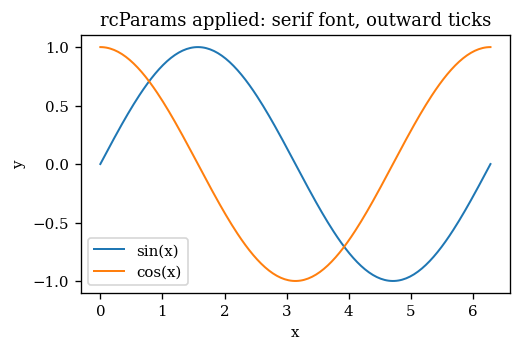

In [3]:
# Set a small group of parameters globally for the rest of this cell block
mpl.rcParams.update({
    'font.family':      'serif',
    'font.size':        9,
    'lines.linewidth':  1.2,
    'xtick.direction':  'out',
    'ytick.direction':  'out',
    'figure.dpi':       120,
})

# A simple figure to confirm the new defaults are active
x_rc = np.linspace(0, 2 * np.pi, 200)
fig_rc, ax_rc = plt.subplots(figsize=(4.5, 3))
ax_rc.plot(x_rc, np.sin(x_rc), label='sin(x)')
ax_rc.plot(x_rc, np.cos(x_rc), label='cos(x)')
ax_rc.set_xlabel('x')
ax_rc.set_ylabel('y')
ax_rc.set_title('rcParams applied: serif font, outward ticks')
ax_rc.legend()
plt.tight_layout()
plt.show()

# Reset to defaults so subsequent cells start clean
mpl.rcdefaults()

Calling `mpl.rcdefaults()` at the end of the cell resets all parameters to the Matplotlib installation defaults. This is good practice in a tutorial notebook where each section should be independent, but in a real project script you would set `rcParams` once at the top and leave them active for the entire session. If you want to reset to the defaults at the start of a script rather than at the end of a cell, `mpl.rcdefaults()` works there too.

## MWD reference data

The molecular weight distribution curve from Module 03 is used throughout this module to make style comparisons on a consistent, recognizable figure.

In [4]:
# Synthetic bimodal MWD: two log-normal peaks
log_m = np.linspace(3.0, 7.0, 600)

def log_normal_peak(log_m, center, height, width):
    return height * np.exp(-((log_m - center) ** 2) / (2 * width ** 2))

mwd_main  = log_normal_peak(log_m, center=5.1, height=1.0, width=0.30)
mwd_high  = log_normal_peak(log_m, center=5.9, height=0.28, width=0.22)
mwd_curve = mwd_main + mwd_high

## 3. Matplotlib style sheets

A style sheet is a `.mplstyle` file that sets a collection of `rcParams` values in one load. Matplotlib ships with a set of built-in styles accessible by name. `plt.style.use()` applies a style for all subsequent figures. Calling it inside a `with plt.style.context()` block applies it only within that block, leaving the global state unchanged afterward.

The same MWD curve drawn under three different built-in styles shows immediately how much visual character comes from style defaults alone.

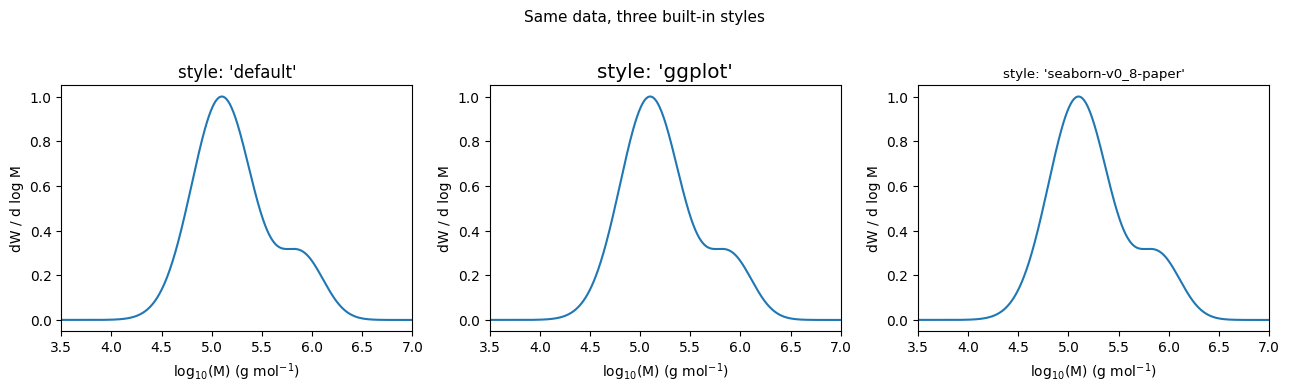

In [5]:
# Use the context manager so each style block is self-contained
styles_to_compare = ['default', 'ggplot', 'seaborn-v0_8-paper']

fig_styles, axes_styles = plt.subplots(1, 3, figsize=(13, 3.8))

for ax_s, style_name in zip(axes_styles, styles_to_compare):
    with plt.style.context(style_name):
        # Draw into the pre-created axes inside the context block
        ax_s.plot(log_m, mwd_curve, linewidth=1.5)
        ax_s.set_xlabel('log$_{10}$(M) (g mol$^{-1}$)')
        ax_s.set_ylabel('dW / d log M')
        ax_s.set_title(f"style: '{style_name}'")
        ax_s.set_xlim(3.5, 7.0)

plt.suptitle('Same data, three built-in styles', y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

`seaborn-v0_8-paper` produces smaller fonts and tighter spacing suited to print; `ggplot` adds a grey background and grid that reads well on screen; the `default` style is neutral but uses sans-serif fonts and inward ticks that most journals prefer changed. Note that `plt.style.context()` is used rather than `plt.style.use()` so the global style is not permanently changed for subsequent cells.

## 4. Writing a custom `.mplstyle` file

A custom style file is the right approach when you have a house style for your group or a journal-specific requirement that goes beyond the built-in options. The file is a plain text file with one `key : value` pair per line. Comments start with `#`. Once created, it is loaded by path with `plt.style.use()` just like a built-in style name.

The style below targets a typical polymer science journal: 8 pt serif font, 1 pt lines, outward ticks, no top or right spines, no grid, and the Okabe-Ito color cycle (introduced in the next section).

In [6]:
os.makedirs('styles', exist_ok=True)

custom_style_text = """\
# custom.mplstyle
# Journal-ready figure style for polymer science manuscripts
# Load with: plt.style.use('styles/custom.mplstyle')

# --- Font ---
font.family        : serif
font.size          : 8
axes.titlesize     : 8
axes.labelsize     : 8
xtick.labelsize    : 7
ytick.labelsize    : 7
legend.fontsize    : 7

# --- Lines ---
lines.linewidth    : 1.0
axes.linewidth     : 0.8

# --- Ticks ---
xtick.direction    : out
ytick.direction    : out
xtick.major.size   : 3.5
ytick.major.size   : 3.5
xtick.minor.size   : 2.0
ytick.minor.size   : 2.0
xtick.major.width  : 0.8
ytick.major.width  : 0.8

# --- Spines: remove top and right ---
axes.spines.top    : False
axes.spines.right  : False

# --- Grid ---
axes.grid          : False

# --- Figure ---
figure.dpi         : 150
savefig.dpi        : 300
savefig.bbox       : tight

# --- Legend ---
legend.frameon     : False
legend.borderpad   : 0.4

# --- Color cycle (Okabe-Ito) ---
axes.prop_cycle    : cycler('color', ['0077BB', '33BBEE', '009988', 'EE7733', 'CC3311', 'EE3377', 'BBBBBB'])
"""

style_path = 'styles/custom.mplstyle'
with open(style_path, 'w') as f:
    f.write(custom_style_text)

print(f'Style file written to: {style_path}')
print(f'Lines: {len(custom_style_text.splitlines())}')

Style file written to: styles/custom.mplstyle
Lines: 45


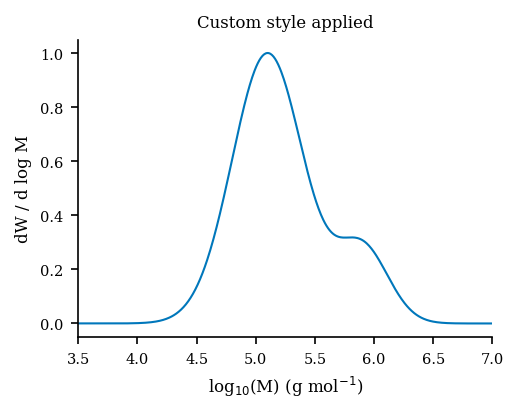

In [7]:
with plt.style.context(style_path):
    fig_cs, ax_cs = plt.subplots(figsize=(3.5, 2.8))
    ax_cs.plot(log_m, mwd_curve)
    ax_cs.set_xlabel('log$_{10}$(M) (g mol$^{-1}$)')
    ax_cs.set_ylabel('dW / d log M')
    ax_cs.set_title('Custom style applied')
    ax_cs.set_xlim(3.5, 7.0)
    plt.tight_layout()
    plt.show()

At 3.5 inches wide the figure is sized for a single journal column. The serif font and 8 pt labels will print at the correct size when the figure is embedded without rescaling. The top and right spines are absent because `axes.spines.top` and `axes.spines.right` are set to `False` in the style file, so every new axes in this style automatically has the open-frame appearance without any per-axes code.

## 5. Color-blind-friendly palettes

Approximately 8% of men and 0.5% of women have some form of color vision deficiency. The most common form confuses red and green. A figure that relies on red-versus-green to distinguish series will be unreadable for a significant fraction of your audience, including reviewers. The Okabe-Ito palette was designed specifically for accessibility: its seven colors are distinguishable under the three most common types of color vision deficiency and print well in greyscale.

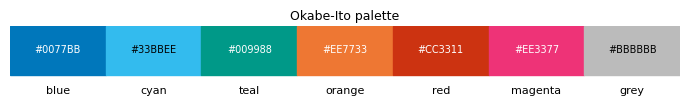

In [8]:
# Okabe-Ito palette: 7 colors, color-vision-deficiency safe
okabe_ito = {
    'blue':          '#0077BB',
    'cyan':          '#33BBEE',
    'teal':          '#009988',
    'orange':        '#EE7733',
    'red':           '#CC3311',
    'magenta':       '#EE3377',
    'grey':          '#BBBBBB',
}

# Show the palette as colored swatches
fig_pal, ax_pal = plt.subplots(figsize=(7, 1.2))
for i, (name, hex_code) in enumerate(okabe_ito.items()):
    ax_pal.add_patch(plt.Rectangle((i, 0), 1, 1, color=hex_code))
    ax_pal.text(i + 0.5, -0.22, name, ha='center', va='top', fontsize=8)
    ax_pal.text(i + 0.5,  0.5,  hex_code, ha='center', va='center',
                fontsize=7, color='white' if name not in ('cyan', 'grey') else 'black')
ax_pal.set_xlim(0, 7)
ax_pal.set_ylim(-0.5, 1)
ax_pal.axis('off')
ax_pal.set_title('Okabe-Ito palette', fontsize=9, pad=4)
plt.tight_layout()
plt.show()

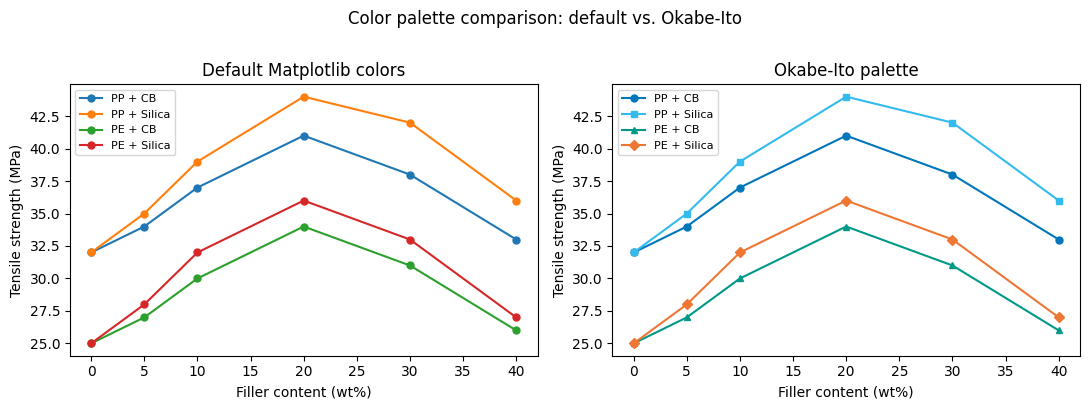

In [9]:
# Synthetic filler-property data: four series for comparison
filler_content = np.array([0, 5, 10, 20, 30, 40])
series_data = {
    'PP + CB':    np.array([32, 34, 37, 41, 38, 33]),
    'PP + Silica': np.array([32, 35, 39, 44, 42, 36]),
    'PE + CB':    np.array([25, 27, 30, 34, 31, 26]),
    'PE + Silica': np.array([25, 28, 32, 36, 33, 27]),
}

okabe_list = list(okabe_ito.values())
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig_cc, (ax_def, ax_oi) = plt.subplots(1, 2, figsize=(11, 4))

# Left: default Matplotlib color cycle
for i, (label, values) in enumerate(series_data.items()):
    ax_def.plot(filler_content, values, marker='o', markersize=5,
                color=default_colors[i % len(default_colors)], label=label)
ax_def.set_xlabel('Filler content (wt%)')
ax_def.set_ylabel('Tensile strength (MPa)')
ax_def.set_title('Default Matplotlib colors')
ax_def.legend(fontsize=8)

# Right: Okabe-Ito palette
markers_oi = ['o', 's', '^', 'D']
for i, (label, values) in enumerate(series_data.items()):
    ax_oi.plot(filler_content, values, marker=markers_oi[i], markersize=5,
               color=okabe_list[i], label=label)
ax_oi.set_xlabel('Filler content (wt%)')
ax_oi.set_ylabel('Tensile strength (MPa)')
ax_oi.set_title('Okabe-Ito palette')
ax_oi.legend(fontsize=8)

plt.suptitle('Color palette comparison: default vs. Okabe-Ito', y=1.01)
plt.tight_layout()
plt.show()

The Okabe-Ito plot also uses distinct marker shapes, not just distinct colors. Using both encoding channels simultaneously means the figure remains interpretable in greyscale print and for readers with any type of color vision. This is a good habit regardless of palette choice: color alone is never sufficient when the series must be unambiguously distinguishable.

## 6. Saving figures for publication

`fig.savefig()` takes several arguments that matter for journal submissions. `dpi=300` sets the output resolution to 300 dots per inch, which is the minimum accepted by most journals for raster formats (PNG, TIFF). `bbox_inches='tight'` trims the saved image to the bounding box of all visible elements, removing blank margins that would otherwise appear. `transparent=True` sets the figure background to transparent, which is useful when figures will be placed on a coloured slide or a page with a non-white background.

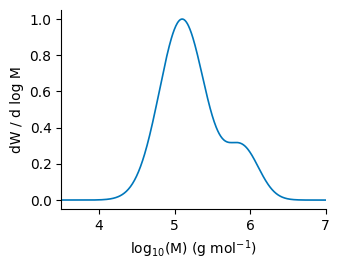

mwd_figure.png                       48.0 KB
mwd_figure.pdf                       10.3 KB
mwd_figure_transparent.png           38.2 KB


In [10]:
fig_save, ax_save = plt.subplots(figsize=(3.5, 2.8))
ax_save.plot(log_m, mwd_curve, color='#0077BB', linewidth=1.2)
ax_save.set_xlabel('log$_{10}$(M) (g mol$^{-1}$)')
ax_save.set_ylabel('dW / d log M')
ax_save.set_xlim(3.5, 7.0)
ax_save.spines['top'].set_visible(False)
ax_save.spines['right'].set_visible(False)
plt.tight_layout()

# Save as PNG at 300 DPI: suitable for most journals
fig_save.savefig(
    'mwd_figure.png',
    dpi=300,                 # 300 DPI: standard minimum for raster submission
    bbox_inches='tight',     # trim white margin around the figure
    transparent=False        # white background for PNG
)

# Save as PDF: vector format, resolution-independent
fig_save.savefig(
    'mwd_figure.pdf',
    bbox_inches='tight'
)

# Save as PNG with a transparent background (for slides or posters)
fig_save.savefig(
    'mwd_figure_transparent.png',
    dpi=300,
    bbox_inches='tight',
    transparent=True         # alpha channel: background is transparent
)

plt.show()

for fname in ['mwd_figure.png', 'mwd_figure.pdf', 'mwd_figure_transparent.png']:
    size_kb = os.path.getsize(fname) / 1024
    print(f'{fname:35s}  {size_kb:.1f} KB')

The PDF is smaller than the PNG here because it stores the figure as vector paths rather than a pixel grid. For figures that contain only lines and text, PDF or SVG is the preferred submission format: the journal's production team can scale it to any size without quality loss. For figures containing rasterized elements (photographic images, certain colormaps rendered at high resolution) PNG at 300 DPI or TIFF is more appropriate.

## 7. Figure sizing for journals

Most journals define figure widths in terms of column layout. A single-column figure must fit within the text column, typically around 3.3 to 3.5 inches (84 to 89 mm). A double-column figure spans the full page width, typically 6.5 to 7.2 inches (165 to 183 mm). Height is usually constrained to keep aspect ratios readable. Setting `figsize` in inches to match the target column width means the figure will appear at the correct size without rescaling when embedded in a Word or LaTeX document at 1:1.

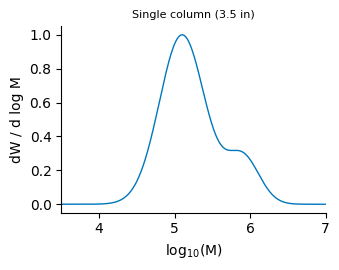

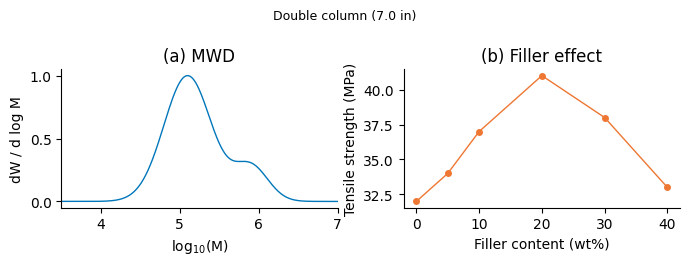

Single column: 3.5 in = 89 mm
Double column: 7.0 in = 178 mm


In [11]:
# Common journal column widths in inches
SINGLE_COL = 3.5    # approximately 89 mm
DOUBLE_COL = 7.0    # approximately 178 mm

# Single-column figure: square-ish aspect ratio
fig_sc, ax_sc = plt.subplots(figsize=(SINGLE_COL, SINGLE_COL * 0.80))
ax_sc.plot(log_m, mwd_curve, color='#0077BB', linewidth=1.0)
ax_sc.set_xlabel('log$_{10}$(M)')
ax_sc.set_ylabel('dW / d log M')
ax_sc.set_title('Single column (3.5 in)', fontsize=8)
ax_sc.set_xlim(3.5, 7.0)
ax_sc.spines['top'].set_visible(False)
ax_sc.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

# Double-column figure: wider with two panels
fig_dc, (ax_dc1, ax_dc2) = plt.subplots(1, 2, figsize=(DOUBLE_COL, DOUBLE_COL * 0.38))

filler_x = np.array([0, 5, 10, 20, 30, 40])
ax_dc1.plot(log_m, mwd_curve, color='#0077BB', linewidth=1.0)
ax_dc1.set_xlabel('log$_{10}$(M)')
ax_dc1.set_ylabel('dW / d log M')
ax_dc1.set_title('(a) MWD')
ax_dc1.set_xlim(3.5, 7.0)
ax_dc1.spines['top'].set_visible(False)
ax_dc1.spines['right'].set_visible(False)

tensile_vals = np.array([32, 34, 37, 41, 38, 33])
ax_dc2.plot(filler_x, tensile_vals, color='#EE7733', marker='o', markersize=4, linewidth=1.0)
ax_dc2.set_xlabel('Filler content (wt%)')
ax_dc2.set_ylabel('Tensile strength (MPa)')
ax_dc2.set_title('(b) Filler effect')
ax_dc2.spines['top'].set_visible(False)
ax_dc2.spines['right'].set_visible(False)

plt.suptitle('Double column (7.0 in)', fontsize=9)
plt.tight_layout()
plt.show()

print(f'Single column: {SINGLE_COL} in = {SINGLE_COL * 25.4:.0f} mm')
print(f'Double column: {DOUBLE_COL} in = {DOUBLE_COL * 25.4:.0f} mm')

The height is set as a fraction of the width to maintain a consistent aspect ratio across different figure widths. A ratio of 0.75 to 0.85 works well for single-panel figures; for two-panel figures a shorter ratio around 0.35 to 0.45 keeps the panels roughly square without making the overall figure too tall. Always check the specific journal's author guidelines for exact dimension requirements.

## 8. Removing top and right spines

The four sides of a Matplotlib axes are called spines. The default shows all four, forming a closed box. Most scientific journals and data visualization style guides recommend removing the top and right spines, leaving an open L-shaped frame. This reduces ink and draws the eye toward the data rather than the axes frame. Each spine is an individual object accessible through `ax.spines`.

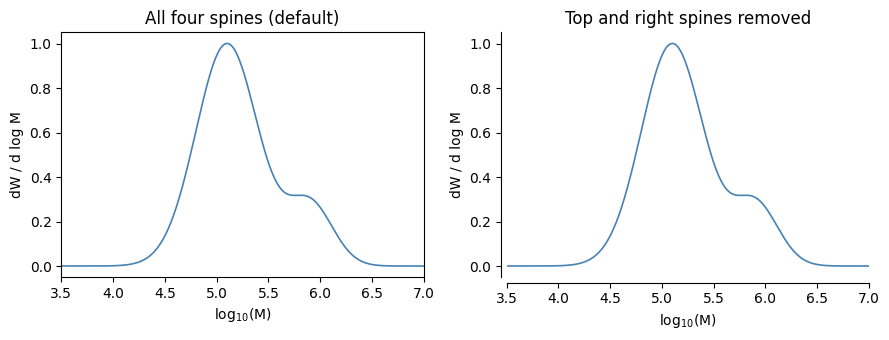

In [12]:
fig_sp, (ax_sp_before, ax_sp_after) = plt.subplots(1, 2, figsize=(9, 3.5))

# Left: all four spines (default)
ax_sp_before.plot(log_m, mwd_curve, color='steelblue', linewidth=1.2)
ax_sp_before.set_xlabel('log$_{10}$(M)')
ax_sp_before.set_ylabel('dW / d log M')
ax_sp_before.set_title('All four spines (default)')
ax_sp_before.set_xlim(3.5, 7.0)

# Right: top and right spines removed
ax_sp_after.plot(log_m, mwd_curve, color='steelblue', linewidth=1.2)
ax_sp_after.set_xlabel('log$_{10}$(M)')
ax_sp_after.set_ylabel('dW / d log M')
ax_sp_after.set_title('Top and right spines removed')
ax_sp_after.set_xlim(3.5, 7.0)

# Accessing each spine by name: 'top', 'bottom', 'left', 'right'
ax_sp_after.spines['top'].set_visible(False)
ax_sp_after.spines['right'].set_visible(False)

# Optionally move the remaining spines outward slightly
ax_sp_after.spines['left'].set_position(('outward', 4))
ax_sp_after.spines['bottom'].set_position(('outward', 4))

plt.tight_layout()
plt.show()

Moving the remaining spines outward by 4 points separates them slightly from the tick marks, which is a common typographic detail in journal figures. If you use the custom style file from section 4, the spines are removed automatically for every figure without this per-axes code. The `spines` dictionary also accepts `set_linewidth`, `set_color`, and `set_bounds` for finer control when needed.

## 9. Before and after: the same figure with and without this module's tools

The two cells below draw the same bimodal MWD with two overlapping series. The first uses every Matplotlib default. The second applies the custom style, Okabe-Ito colors, correct figure sizing, spine removal, and proper save settings.

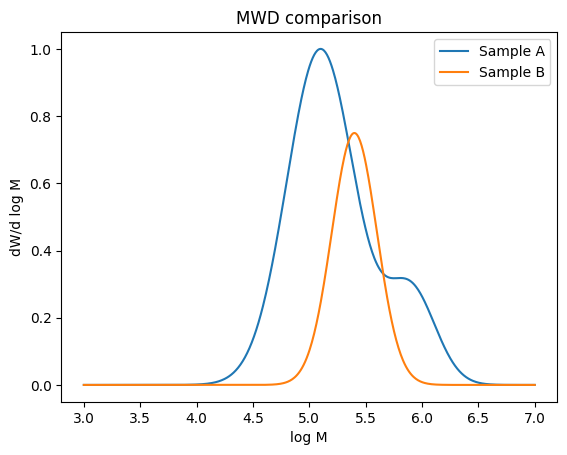

In [13]:
# Second MWD series: slightly higher Mw, narrower
mwd_narrow = log_normal_peak(log_m, center=5.4, height=0.75, width=0.20)

# ---- BEFORE: pure Matplotlib defaults ----
fig_before, ax_before = plt.subplots()
ax_before.plot(log_m, mwd_curve,  label='Sample A')
ax_before.plot(log_m, mwd_narrow, label='Sample B')
ax_before.set_xlabel('log M')
ax_before.set_ylabel('dW/d log M')
ax_before.set_title('MWD comparison')
ax_before.legend()
plt.show()

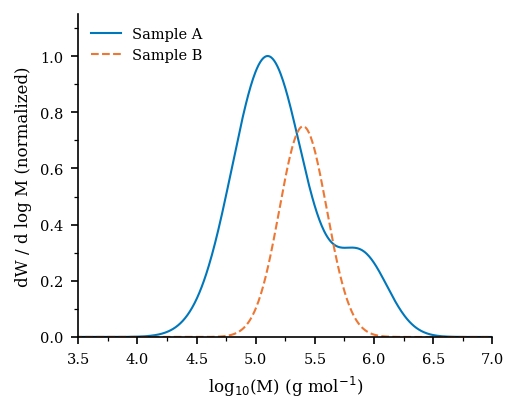

Saved: mwd_publication.pdf and mwd_publication.png


In [14]:
# ---- AFTER: custom style + all techniques from this module ----
with plt.style.context(style_path):
    fig_after, ax_after = plt.subplots(figsize=(3.5, 2.8))

    ax_after.plot(log_m, mwd_curve,
                  color='#0077BB', linewidth=1.0, label='Sample A')
    ax_after.plot(log_m, mwd_narrow,
                  color='#EE7733', linewidth=1.0, linestyle='--', label='Sample B')

    ax_after.set_xlabel('log$_{10}$(M) (g mol$^{-1}$)')
    ax_after.set_ylabel('dW / d log M (normalized)')
    ax_after.set_xlim(3.5, 7.0)
    ax_after.set_ylim(0, 1.15)

    # Minor ticks on both axes
    ax_after.xaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))
    ax_after.yaxis.set_minor_locator(mpl.ticker.AutoMinorLocator(2))

    ax_after.legend(loc='upper left')

    plt.tight_layout()

    # Save at publication resolution
    fig_after.savefig('mwd_publication.pdf', bbox_inches='tight')
    fig_after.savefig('mwd_publication.png', dpi=300, bbox_inches='tight')

    plt.show()

print('Saved: mwd_publication.pdf and mwd_publication.png')

The before figure uses the Matplotlib default: 6.4 by 4.8 inches, DejaVu Sans, inward ticks, a closed four-sided frame, and the default blue-orange color cycle. The after figure is 3.5 inches wide, uses a serif font at 8 pt, outward ticks, an open L-frame, and the Okabe-Ito palette with both color and line style differentiating the two series. Every visual property is set by the style file rather than per-axes code, so the same output would appear for any figure using `plt.style.context(style_path)`. That is the full value of systematic styling: you write the choices once and they apply everywhere.